# Assignment 4 — Problem Formulation

**Course:** EPA141A Model Based Decision Making — Delft University of Technology  
**Model:** JUSTICE  
**Actor 15 — Japan & South Korea (Bloc 4, High Ambition Coalition)**

---

## Learning Outcomes

1. Complete the **XLRM framework** for a climate policy problem under deep uncertainty.
2. Translate **justice principles** into formally specified measurable objectives.
3. Understand the **adaptive policy representation** (EMODPS with RBFs).
4. Explore the design space of possible ECR policies.
5. Formally structure a many-objective optimisation problem and articulate the assumptions embedded in it.

---

## Background

Problem formulation is the first step in structuring a many-objective optimisation problem. Before an MOEA can search for Pareto-optimal policies, we must decide *what* to optimise (objectives), *what* we can control (levers), *what* we cannot control (uncertainties), and *what* model relationships connect them. The **XLRM framework** — eXogenous uncertainties, Levers, Relationships, and Measures of performance — provides a systematic structure for this.

In JUSTICE, climate policies are represented as **adaptive emission control rate (ECR) pathways** generated by **radial basis functions (RBFs)**. Rather than pre-specifying a fixed time-schedule for emission reductions, RBFs map the current climate state (global temperature level and its rate of change) to an emission control rate for each of the 57 RICE50 regions. This **closed-loop** formulation means policies automatically adapt to how the climate actually evolves, rather than following a pre-planned calendar schedule — a key advantage under deep uncertainty about climate sensitivity.

The MOEA in Assignment 5 will search over the **244 RBF parameters** (centers, radii, and weights) to find combinations that simultaneously minimise multiple objectives. A critical design choice is the **social welfare function**: different aggregation methods (Utilitarian, Prioritarian, Sufficientarian) encode different ethical principles about equity between regions, and each produces a different Pareto front. The problem formulation therefore embeds normative assumptions that directly shape the solution space explored in Assignment 5.

### Our actor: Japan & South Korea

We are two major developed, technology-exporting economies that favour **technology-led** decarbonisation — hydrogen, ammonia, carbon capture — over rapid fossil-fuel switching. Three commitments from our mandate shape every choice in this notebook:

- **Technology neutrality.** The agreement should fix the temperature *outcome* and leave the *route* to each actor. The adaptive RBF policy, which conditions abatement on the realised climate state rather than on a prescribed schedule, is the natural modelling analogue of this position.
- **Overshoot tolerance.** A pathway that temporarily overshoots 2°C and then returns below it is legitimate for us, **provided near-term damage to the most vulnerable stays bounded**. This makes the overshoot interval and the damage to exposed regions (`rcam`, `rjan57`) the quantities we most need to measure.
- **Both welfare lenses.** A **Utilitarian** frame carries our efficiency argument (a technology-led path is acceptable if the long-run target is met); a **Prioritarian** frame — extra weight to the worst-off — is what Bloc 1 will use to ask who lives through the overshoot. We optimise primarily on the first and retain the second as the rival lens.

One honest caveat throughout: JUSTICE is **technology-blind** (one ECR per region, an Enerdata cost curve, no explicit hydrogen/ammonia/CCS). We therefore argue our technologies through *outcome-equivalent* ECR pathways, not as named technologies, and flag this as a limitation wherever it bites.

---


## Setup — Imports and model configuration

The cell below imports all required packages, configures the EMA Workbench logging level, and initialises the DataLoader and geometric constants (number of regions, timesteps, RBF architecture parameters) that are referenced throughout the assignment.

In [1]:
import os, sys
# ── Add JUSTICE-main to sys.path so justice internal imports resolve ───────────
_here         = os.path.abspath('.')   # CWD = notebook dir in JupyterLab
_justice_root = os.path.normpath(os.path.join(_here, '../JUSTICE-main'))
_NOTEBOOK_DIR = _here

_PLOTS_DIR = os.path.join(_NOTEBOOK_DIR, "plots")
os.makedirs(_PLOTS_DIR, exist_ok=True)
if _justice_root not in sys.path:
    sys.path.insert(0, _justice_root)
os.chdir(_justice_root)

import warnings; warnings.filterwarnings("ignore")
import importlib, sys, os
import multiprocessing
try:
    multiprocessing.set_start_method('fork')
except RuntimeError:
    pass  # already set

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from ema_workbench import (
    Model, RealParameter, IntegerParameter, CategoricalParameter,
    ScalarOutcome, ArrayOutcome,
    perform_experiments, ema_logging,
    SequentialEvaluator, MultiprocessingEvaluator,
)
from justice.model import JUSTICE
from justice.util.enumerations import WelfareFunction
from justice.util.data_loader import DataLoader
from justice.objectives.objective_functions import years_above_temperature_threshold

import matplotlib.path as _mpath
def _patched_path_deepcopy(self, memo=None):
    if memo is None: memo = {}
    new_path = _mpath.Path.__new__(_mpath.Path)
    memo[id(self)] = new_path
    verts = self._vertices.copy()
    codes = self._codes.copy() if self._codes is not None else None
    new_path.__init__(verts, codes,
                      _interpolation_steps=self._interpolation_steps, readonly=False)
    return new_path
_mpath.Path.__deepcopy__ = _patched_path_deepcopy

ema_logging.log_to_stderr(ema_logging.INFO)

N_REGIONS   = 57
N_TIMESTEPS = 286
N_RBFS      = 4
N_INPUTS    = 2

years   = np.arange(2015, 2301)
tau_hat = np.clip((years - 2015) / (2100 - 2015), 0, 1)
s_curve = 3 * tau_hat**2 - 2 * tau_hat**3

dl = DataLoader()

required = ["justice", "numpy", "pandas", "matplotlib", "ema_workbench", "scipy", "seaborn"]
for pkg in required:
    found = importlib.util.find_spec(pkg) is not None
    print(f"  {'✓' if found else '✗'}  {pkg}")
print(f"\nPython {sys.version.split()[0]}")
print(f"DataLoader ready — {len(dl.REGION_LIST)} regions, {N_TIMESTEPS} timesteps")

  ✓  justice
  ✓  numpy
  ✓  pandas
  ✓  matplotlib
  ✓  ema_workbench
  ✓  scipy
  ✓  seaborn

Python 3.12.13
DataLoader ready — 57 regions, 286 timesteps


---

## Step 1 — Complete the XLRM framework

**Task 1.1** — Add items to each XLRM category. The pre-filled items are simply suggestions.

**Task 1.2** — For each item you add, identify its EMA Workbench counterpart:
- Uncertainties (X) → `RealParameter` or `CategoricalParameter` on `em_model.uncertainties`
- Levers (L) → `RealParameter` on `em_model.levers`
- Measures (M) → `ScalarOutcome` on `em_model.outcomes`

This mapping defines the search space and the objective
space for the MOEA in Assignment 5.

In [2]:
xlrm = {
    "X — Uncertainties": [
        "ecs_ensemble: FaIR ensemble member — selects the physical ECS realisation [1, 1001]; the high-ECS tail is what turns our bounded overshoot into a deep one",
        "scenario: SSP-RCP pathway index {SSP1-1.9 ... SSP5-8.5} (categorical) — the background emissions trajectory we must adapt to",
        "delta: damage function scale factor — structural uncertainty in damage estimates [0.5, 2.0]; scales near-term damage to exposed regions (rcam, rjan57)",
        "eta: elasticity of marginal utility — normative uncertainty controlling how much extra weight the worst-off receive [0.5, 2.5]; the parameter behind Bloc 1's prioritarian challenge",
    ],
    "L — Levers": [
        "RBF adaptive policy: 244 parameters (centers, radii, weights) searched by the MOEA — an outcome-conditioned decision rule, i.e. the modelling analogue of our technology-neutrality demand (fix the target, not the route)",
    ],
    "R — Relationships (the model)": [
        "JUSTICE IAM: neoclassical economy x Kalkuhl damage x Enerdata abatement",
        "Climate module: FaIR temperature response from cumulative emissions",
        "Welfare aggregation: Utilitarian (primary, efficiency lens), with Prioritarian retained as the worst-off rival lens our mandate requires",
        "Regional damage: temperature x damage_gdp_ratio_with_threshold per region — the channel through which the overshoot interval hurts vulnerable regions",
        "Abatement cost: Enerdata backstop curves per sector per region",
        "Model caveat: JUSTICE is technology-blind (a single ECR per region), so hydrogen, ammonia and CCS cannot be represented explicitly — we argue them through outcome-equivalent ECR pathways",
        "Japan (jpn) and South Korea (cor) are technology-exporting economies — global decarbonisation expands their export markets, so abatement cost is not purely a domestic burden",
    ],
    "M — Measures of performance": [
        "welfare: aggregate Utilitarian welfare-loss magnitude — equal weight to every person across all 57 regions; lower is better (MINIMISE)",
        "fraction_above_threshold: fraction of the FaIR ensemble above 2C in 2100 — our mandate's direction-2 climate test (MINIMISE)",
        "welfare_loss_damage: welfare loss from climate damages — captures typhoon, flood and sea-level risk to jpn, cor and the exposed regions (MINIMISE)",
        "welfare_loss_abatement: welfare loss from abatement cost — the efficiency price of mitigation, central to our utilitarian argument (MINIMISE)",
    ],
}

df_xlrm = pd.DataFrame(
    [(cat, item) for cat, items in xlrm.items() for item in items],
    columns=["Component", "Item"]
)
with pd.option_context("display.max_colwidth", 110):
    display(df_xlrm)

ema_mapping = pd.DataFrame([
    ("X — Uncertainties", "ecs_ensemble",           "RealParameter [1,1001]",   "em_model.uncertainties"),
    ("X — Uncertainties", "scenario (SSP)",          "CategoricalParameter",     "em_model.uncertainties"),
    ("X — Uncertainties", "delta",                   "RealParameter [0.5, 2.0]", "em_model.uncertainties"),
    ("X — Uncertainties", "eta",                     "RealParameter [0.5, 2.5]", "em_model.uncertainties"),
    ("L — Levers",        "RBF centers c_i_j",       "RealParameter [0,1]",      "em_model.levers"),
    ("L — Levers",        "RBF radii r_i_j",         "RealParameter [0,0.5]",    "em_model.levers"),
    ("L — Levers",        "RBF weights w_k_i",       "RealParameter [-1,1]",     "em_model.levers"),
    ("M — Measures",      "welfare (Utilitarian)",   "ScalarOutcome MINIMIZE",   "em_model.outcomes"),
    ("M — Measures",      "fraction_above_threshold","ScalarOutcome MINIMIZE",   "em_model.outcomes"),
    ("M — Measures",      "welfare_loss_damage",     "ScalarOutcome MINIMIZE",   "em_model.outcomes"),
    ("M — Measures",      "welfare_loss_abatement",  "ScalarOutcome MINIMIZE",   "em_model.outcomes"),
], columns=["XLRM", "Variable", "EMA type", "Assignment to"])

print("\nXLRM → EMA Workbench mapping:")
display(ema_mapping)


,Component,Item
0,X — Uncertainties,"ecs_ensemble: FaIR ensemble member — selects the physical ECS realisation [1, 1001]; the high-ECS tail is ..."
1,X — Uncertainties,scenario: SSP-RCP pathway index {SSP1-1.9 ... SSP5-8.5} (categorical) — the background emissions trajector...
2,X — Uncertainties,"delta: damage function scale factor — structural uncertainty in damage estimates [0.5, 2.0]; scales near-t..."
3,X — Uncertainties,eta: elasticity of marginal utility — normative uncertainty controlling how much extra weight the worst-of...
4,L — Levers,"RBF adaptive policy: 244 parameters (centers, radii, weights) searched by the MOEA — an outcome-conditione..."
5,R — Relationships (the model),JUSTICE IAM: neoclassical economy x Kalkuhl damage x Enerdata abatement
6,R — Relationships (the model),Climate module: FaIR temperature response from cumulative emissions
7,R — Relationships (the model),"Welfare aggregation: Utilitarian (primary, efficiency lens), with Prioritarian retained as the worst-off r..."
8,R — Relationships (the model),Regional damage: temperature x damage_gdp_ratio_with_threshold per region — the channel through which the ...
9,R — Relationships (the model),Abatement cost: Enerdata backstop curves per sector per region



XLRM → EMA Workbench mapping:


,XLRM,Variable,EMA type,Assignment to
0,X — Uncertainties,ecs_ensemble,"RealParameter [1,1001]",em_model.uncertainties
1,X — Uncertainties,scenario (SSP),CategoricalParameter,em_model.uncertainties
2,X — Uncertainties,delta,"RealParameter [0.5, 2.0]",em_model.uncertainties
3,X — Uncertainties,eta,"RealParameter [0.5, 2.5]",em_model.uncertainties
4,L — Levers,RBF centers c_i_j,"RealParameter [0,1]",em_model.levers
5,L — Levers,RBF radii r_i_j,"RealParameter [0,0.5]",em_model.levers
6,L — Levers,RBF weights w_k_i,"RealParameter [-1,1]",em_model.levers
7,M — Measures,welfare (Utilitarian),ScalarOutcome MINIMIZE,em_model.outcomes
8,M — Measures,fraction_above_threshold,ScalarOutcome MINIMIZE,em_model.outcomes
9,M — Measures,welfare_loss_damage,ScalarOutcome MINIMIZE,em_model.outcomes


## Step 2 — Justice principles

**Task 2.1** — Run JUSTICE under BAU (no abatement) with three welfare functions and compare results.

> **Key insight:** What changes is how welfare losses are aggregated, which determines the shape of the objective landscape the MOEA will search. The choice of welfare function therefore changes the Pareto front.

For Actor 15 this is not just a technical detail. Our mandate is explicit that we need **both** lenses: the **Utilitarian** result carries our efficiency argument (a technology-led pathway is acceptable as long as the long-run target is met), while the **Prioritarian** result is what Bloc 1 invokes to ask who lives through the overshoot interval and what it costs them. The comparison below shows how differently the two aggregate the same underlying damages.

In [3]:
welfare_functions = {
    "Utilitarian"    : WelfareFunction.UTILITARIAN,
    "Prioritarian"   : WelfareFunction.PRIORITARIAN,
    "Sufficientarian": WelfareFunction.SUFFICIENTARIAN,
}

ecr_bau = np.zeros((N_REGIONS, N_TIMESTEPS))

results_wf = {}
for wf_name, wf in welfare_functions.items():
    JUSTICE.hard_reset()
    model = JUSTICE(
        start_year=2015, end_year=2300, timestep=1,
        scenario=2, climate_ensembles=1, stochastic_run=False,
        social_welfare_function=wf,
    )
    model.run(emission_control_rate=ecr_bau, endogenous_savings_rate=True)
    datasets = model.evaluate()

    wf_val = float(np.abs(datasets["welfare"]))
    yat    = float(years_above_temperature_threshold(datasets["global_temperature"], 2.0))
    _, _, _, wl_dam = model.welfare_function.calculate_welfare(
        datasets["damage_cost_per_capita"], welfare_loss=True)
    _, _, _, wl_abt = model.welfare_function.calculate_welfare(
        datasets["abatement_cost_per_capita"], welfare_loss=True)

    results_wf[wf_name] = {
        "welfare":               wf_val,
        "years_above_2C":        yat,
        "welfare_loss_damage":   float(np.abs(wl_dam)),
        "welfare_loss_abatement":float(np.abs(wl_abt)),
    }
    print(f"  {wf_name}: welfare={wf_val:.6f}, years>2°C={yat:.1f}")

df_wf = pd.DataFrame(results_wf).T.round(4)
print("\nComparison table:")
display(df_wf)

  Utilitarian: welfare=103.721111, years>2°C=259.0
  Prioritarian: welfare=414.827668, years>2°C=259.0
  Sufficientarian: welfare=104.187375, years>2°C=259.0

Comparison table:


,welfare,years_above_2C,welfare_loss_damage,welfare_loss_abatement
Utilitarian,103.7211,259.0,3980.5410,74364.1321
Prioritarian,414.8277,259.0,18888.6964,318818.3307
Sufficientarian,104.1874,259.0,3980.5410,74364.1321


## Step 3 — Explore the ECR policy design space

**Task 3.1** — Plot 5 different ECR profiles. This illustrates that the MOEA must search
over an enormous space of possible emission pathways, not just a single scalar.

> **Why this matters:** The 244 RBF decision variables can produce any combination of
> these profiles — and infinitely many more — per region per year. The plots below
> capture only a tiny 1D slice of that space.

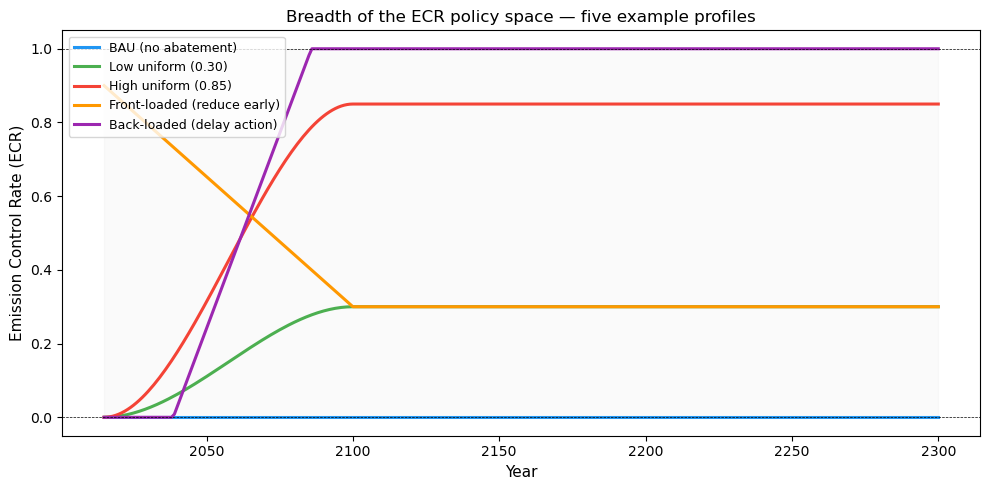

Saved: a04ema_ecr_profiles.png


In [4]:
profiles = {
    "BAU (no abatement)"          : np.zeros(N_TIMESTEPS),
    "Low uniform (0.30)"          : 0.30 * s_curve,
    "High uniform (0.85)"         : 0.85 * s_curve,
    "Front-loaded (reduce early)" : np.clip(0.9 - 0.6 * tau_hat, 0, 1),
    "Back-loaded (delay action)"  : np.clip(1.8 * tau_hat - 0.5,  0, 1),
}

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2196F3", "#4CAF50", "#F44336", "#FF9800", "#9C27B0"]
for (name, profile), color in zip(profiles.items(), colors):
    ax.plot(years, profile, label=name, color=color, linewidth=2.2)

ax.fill_between(years, 0, 1, alpha=0.04, color="grey")
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Emission Control Rate (ECR)", fontsize=11)
ax.set_title("Breadth of the ECR policy space — five example profiles", fontsize=12)
ax.legend(fontsize=9, loc="upper left")
ax.set_ylim(-0.05, 1.05)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.axhline(1, color="black", linewidth=0.5, linestyle="--")
plt.tight_layout()
display(fig)
plt.savefig(os.path.join(_PLOTS_DIR, "a04ema_ecr_profiles.png"), dpi=150, bbox_inches="tight")
print("Saved: a04ema_ecr_profiles.png")
plt.close(fig)

## Step 4 — Adaptive policies with RBFs: decision variable structure

**Task 4.1** — Calculate the exact number of decision variables.

**Task 4.2** — A fixed time-path ECR maps *year → action*: rigid, insensitive to
whether ECS turns out high or low. An RBF policy maps *current state → action*: if temperature
tracks below 2°C the RBF returns lower abatement; if overshooting it increases it automatically.
The decision variables encode a **decision rule**, not a **decision sat every time step** — that is what
makes it adaptive (EMODPS principle).

In [5]:
n_rbfs   = N_RBFS      # 4
n_inputs = N_INPUTS    # 2  (temperature deviation, cumulative emissions)
n_outputs = N_REGIONS  # 57 (ECR for each region)

# Decision variable breakdown
# The formula is:  2 × (n_rbfs × n_inputs)  +  n_outputs × n_rbfs
# The factor of 2 accounts for BOTH centers AND radii (one value per RBF per input each)
n_centers = n_rbfs * n_inputs           # 8
n_radii   = n_rbfs * n_inputs           # 8
n_weights = n_outputs * n_rbfs          # 228
n_total   = 2 * (n_rbfs * n_inputs) + n_outputs * n_rbfs

breakdown = pd.DataFrame({
    "Component": ["Centers c_{i,j}", "Radii r_{i,j}", "Weights w_{k,i}", "TOTAL"],
    "Count":     [n_centers,          n_radii,          n_weights,         n_total],
    "Formula":   ["n_rbfs × n_inputs","n_rbfs × n_inputs","n_outputs × n_rbfs",
                  "2×(n_rbfs×n_inputs) + n_outputs×n_rbfs"],
    "Value":     [f"{n_rbfs}×{n_inputs}={n_centers}",
                  f"{n_rbfs}×{n_inputs}={n_radii}",
                  f"{n_outputs}×{n_rbfs}={n_weights}",
                  f"2×{n_rbfs*n_inputs}+{n_weights}={n_total}"],
})
display(breakdown)
print(f"\nTotal RBF decision variables: {n_total}")
assert n_total == 244, f"Expected 244, got {n_total}"
print("✓ matches assignment specification")

,Component,Count,Formula,Value
0,"Centers c_{i,j}",8,n_rbfs × n_inputs,4×2=8
1,"Radii r_{i,j}",8,n_rbfs × n_inputs,4×2=8
2,"Weights w_{k,i}",228,n_outputs × n_rbfs,57×4=228
3,TOTAL,244,2×(n_rbfs×n_inputs) + n_outputs×n_rbfs,2×8+228=244



Total RBF decision variables: 244
✓ matches assignment specification


## RBF adaptive policy

The helper below replicates the RBF formulation used by JUSTICE. Each basis function computes a Gaussian response to the current climate state (scaled temperature and warming rate), and the weighted sum of all basis functions determines the emission control rate prescribed to each of the 57 regions.

The demo parameters below are for illustration only — centers are sampled from [0, 1], radii from [0.05, 0.3]. The actual optimization in Assignment 5 searches over a wider space: centers ∈ [-1, 1] and radii ∈ [0, 1], allowing the MOEA to place basis functions anywhere in the (extended) state space and control how broadly or narrowly each one responds.

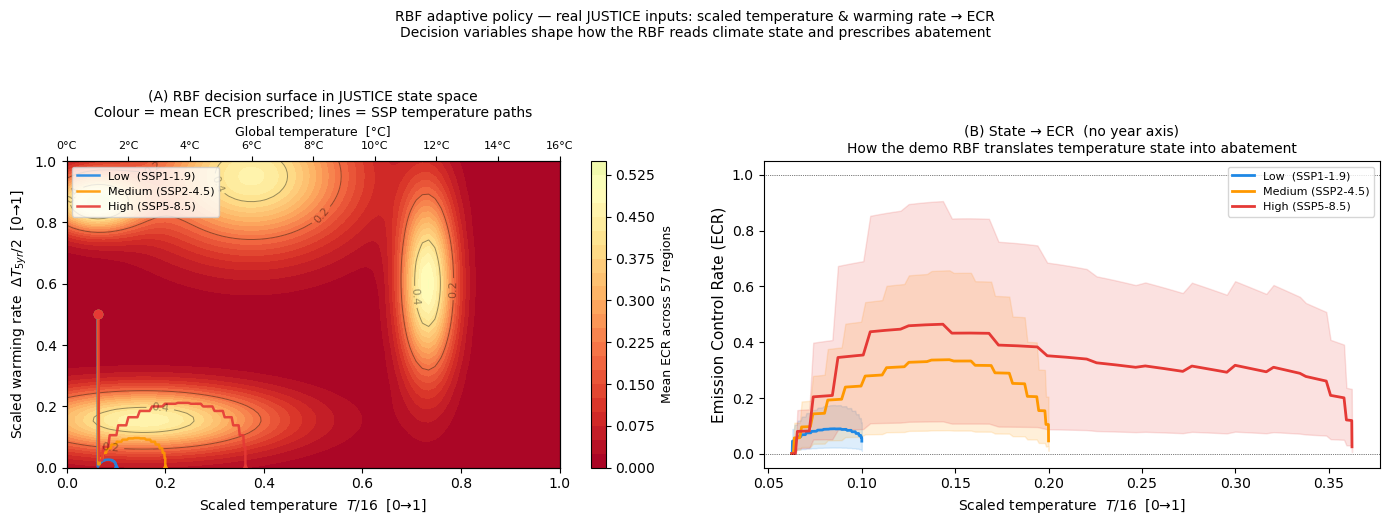

Saved: a04ema_rbf_policy_visual.png


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# RBF helper — matches JUSTICE's original_rbf (weights shape: n_rbfs × n_outputs)
# ─────────────────────────────────────────────────────────────────────────────

def rbf_policy(state_vector, centers, radii, weights):
    """
    state_vector : (n_inputs,)
    centers      : (n_rbfs, n_inputs)
    radii        : (n_rbfs, n_inputs)
    weights      : (n_rbfs, n_outputs)   ← matches JUSTICE convention
    returns      : (n_outputs,)  ECR clipped to [0, 1]
    """
    phi = np.exp(-np.sum(((state_vector - centers) / (radii + 1e-6))**2, axis=1))
    weighted = weights * phi[:, np.newaxis]   # (n_rbfs, n_outputs)
    return np.clip(weighted.sum(axis=0), 0.0, 1.0)


# Demo parameters  (weights now n_rbfs × n_outputs to match JUSTICE)
np.random.seed(42)
demo_centers = np.random.uniform(0.0, 1.0, (N_RBFS, N_INPUTS))
demo_radii   = np.random.uniform(0.05, 0.3,  (N_RBFS, N_INPUTS))
demo_weights = np.random.uniform(0.0,  1.0,  (N_RBFS, N_REGIONS))   # [0,1] per JUSTICE

# ─────────────────────────────────────────────────────────────────────────────
# JUSTICE scaling constants  (from EMA_model_wrapper.py)
# ─────────────────────────────────────────────────────────────────────────────
T_MIN, T_MAX = 0.0, 16.0   # global temperature  [°C]
D_MIN, D_MAX = 0.0,  2.0   # 5-step temp change  [°C per 5 years]

# ─────────────────────────────────────────────────────────────────────────────
# Synthetic SSP-like temperature trajectories (anomaly from ~0°C baseline)
# ─────────────────────────────────────────────────────────────────────────────
def smooth_rise(t_norm, t_end, t_start=1.0):
    """S-curve from t_start to t_end over the simulation."""
    return t_start + (t_end - t_start) * (3*t_norm**2 - 2*t_norm**3)

scenarios = {
    'Low  (SSP1-1.9)':    (smooth_rise(tau_hat, 1.6),  '#1E88E5'),
    'Medium (SSP2-4.5)':  (smooth_rise(tau_hat, 3.2),  '#FF9800'),
    'High (SSP5-8.5)':    (smooth_rise(tau_hat, 5.8),  '#E53935'),
}

def compute_difference_signal(temp_traj):
    """Replicate JUSTICE: difference updated every 5 timesteps."""
    diff  = np.zeros(N_TIMESTEPS)
    prev  = 0.0
    for t in range(N_TIMESTEPS):
        if t % 5 == 0:
            diff[t] = temp_traj[t] - prev
            prev     = temp_traj[t]
        else:
            diff[t]  = diff[t-1] if t > 0 else 0.0
    return diff

# Scale to [0,1] using JUSTICE constants and compute ECR for each scenario
scenario_data = {}
for name, (temp_traj, color) in scenarios.items():
    diff_traj  = compute_difference_signal(temp_traj)
    sc_temp    = (temp_traj - T_MIN) / (T_MAX - T_MIN)
    sc_diff    = np.clip((diff_traj - D_MIN) / (D_MAX - D_MIN), 0, 1)
    ecr_all    = np.array([
        rbf_policy(np.array([sc_temp[t], sc_diff[t]]), demo_centers, demo_radii, demo_weights)
        for t in range(N_TIMESTEPS)
    ])   # (N_TIMESTEPS, N_REGIONS)
    scenario_data[name] = dict(
        sc_temp=sc_temp, sc_diff=sc_diff,
        ecr_mean=ecr_all.mean(axis=1),
        ecr_p10=np.percentile(ecr_all, 10, axis=1),
        ecr_p90=np.percentile(ecr_all, 90, axis=1),
        color=color,
    )

# ─────────────────────────────────────────────────────────────────────────────
# Decision surface over the real JUSTICE state space
# ─────────────────────────────────────────────────────────────────────────────
n_grid   = 80
t_axis   = np.linspace(0, 1, n_grid)   # scaled temperature    (0–16°C)
d_axis   = np.linspace(0, 1, n_grid)   # scaled temp change    (0–2°C/5yr)
TG, DG   = np.meshgrid(t_axis, d_axis)

ecr_surface = np.zeros((n_grid, n_grid))
for i in range(n_grid):
    for j in range(n_grid):
        ecr_surface[i, j] = rbf_policy(
            np.array([TG[i, j], DG[i, j]]), demo_centers, demo_radii, demo_weights
        ).mean()

# ─────────────────────────────────────────────────────────────────────────────
# Figure
# Panel A : 2-D decision surface  (real JUSTICE state space)
# Panel B : ECR vs scaled temperature  (no year axis)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# — Panel A —
ax = axes[0]
cf = ax.contourf(t_axis, d_axis, ecr_surface, levels=25, cmap='RdYlGn', vmin=0, vmax=1)
cs = ax.contour(t_axis, d_axis, ecr_surface,
                levels=[0.2, 0.4, 0.6, 0.8],
                colors='black', linewidths=0.7, alpha=0.4)
ax.clabel(cs, fmt='%.1f', fontsize=8)
plt.colorbar(cf, ax=ax).set_label('Mean ECR across 57 regions', fontsize=9)

for name, d in scenario_data.items():
    ax.plot(d['sc_temp'], d['sc_diff'], color=d['color'], linewidth=1.8,
            label=name, alpha=0.9)
    ax.plot(d['sc_temp'][0],  d['sc_diff'][0],  'o', color=d['color'], ms=6, zorder=5)
    ax.plot(d['sc_temp'][-1], d['sc_diff'][-1], '^', color=d['color'], ms=6, zorder=5)

# Annotate real-world temperature labels on x-axis
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
tick_temps = [0, 2, 4, 6, 8, 10, 12, 14, 16]
ax2.set_xticks([t / T_MAX for t in tick_temps])
ax2.set_xticklabels([f'{t}°C' for t in tick_temps], fontsize=8)
ax2.set_xlabel('Global temperature  [°C]', fontsize=9)

ax.set_xlabel('Scaled temperature  $T / 16$  [0→1]', fontsize=10)
ax.set_ylabel('Scaled warming rate  $\\Delta T_{5yr} / 2$  [0→1]', fontsize=10)
ax.set_title('(A) RBF decision surface in JUSTICE state space\n'
             'Colour = mean ECR prescribed; lines = SSP temperature paths',
             fontsize=10)
ax.legend(fontsize=8, loc='upper left')

# — Panel B —
ax = axes[1]
for name, d in scenario_data.items():
    ax.fill_between(d['sc_temp'], d['ecr_p10'], d['ecr_p90'],
                    alpha=0.15, color=d['color'])
    ax.plot(d['sc_temp'], d['ecr_mean'], color=d['color'],
            linewidth=2.0, label=name)

ax.set_xlabel('Scaled temperature  $T / 16$  [0→1]', fontsize=10)
ax.set_ylabel('Emission Control Rate (ECR)', fontsize=11)
ax.set_title('(B) State → ECR  (no year axis)\n'
             'How the demo RBF translates temperature state into abatement',
             fontsize=10)
ax.legend(fontsize=8)
ax.set_ylim(-0.05, 1.05)
ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax.axhline(1, color='black', linewidth=0.5, linestyle=':')

plt.suptitle(
    'RBF adaptive policy — real JUSTICE inputs: scaled temperature & warming rate → ECR\n'
    'Decision variables shape how the RBF reads climate state and prescribes abatement',
    fontsize=10, y=1.04,
)
plt.tight_layout()
display(fig)
plt.savefig(os.path.join(_PLOTS_DIR, "a04ema_rbf_policy_visual.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved: a04ema_rbf_policy_visual.png")

## Step 5 — Define the multi-objective optimisation problem

This step translates the XLRM framework and RBF policy structure from the previous steps into a concrete optimisation configuration. You will make four decisions that together define the problem:

1. **Social welfare function** — whose preferences does the model represent?
2. **Reference SSP-RCP scenario** — under what emissions pathway do you optimise?
3. **FaIR ensemble strategy** — how do you represent deep climate uncertainty efficiently?
4. **Objectives and ε-resolution** — what do you optimise, in which direction, and how finely?

The result is saved as `config/config_student.json` inside `JUSTICE-main/`. Assignment 5 loads this file directly to configure every aspect of the MOEA run.

### Task 5.1 — Choose a social welfare function

JUSTICE supports multiple social welfare functions (you explored them in Step 2). \
The MOEA will optimise the 244 RBF parameters to minimise welfare loss as measured \
by whichever function you select here.

**Question:** Which welfare function should the reference optimisation use, and why?

In [7]:
WELFARE_OPTIONS = {
    "Utilitarian"    : WelfareFunction.UTILITARIAN,
}

print("Welfare functions considered:")
for name, wf in WELFARE_OPTIONS.items():
    print(f"  {name:<20s}  internal index = {wf.value[0]}")

# ── Our choice ───────────────────────────────────────────────────────────────
# Utilitarian is our PRIMARY (efficiency) lens: it sums per-capita welfare across
# all 57 regions and lets a technology-led pathway score well as long as the
# long-run temperature target is met — the core of our mandate's efficiency case.
# We deliberately keep PRIORITARIAN (extra weight to the worst-off) as the rival
# lens for the overshoot question Bloc 1 will press, and revisit it in the
# robustness analysis. Our mandate states we need both.
CHOSEN_WELFARE_FUNCTION     = WelfareFunction.UTILITARIAN
CHOSEN_WELFARE_FUNCTION_IDX = CHOSEN_WELFARE_FUNCTION.value[0]

print(f"\nChosen (primary): {CHOSEN_WELFARE_FUNCTION.name}  (index {CHOSEN_WELFARE_FUNCTION_IDX})")
print("Rationale: efficiency lens — sums per-capita welfare across all regions;")
print("Prioritarian retained as the worst-off rival lens for the overshoot challenge.")


Welfare functions considered:
  Utilitarian           internal index = 0

Chosen (primary): UTILITARIAN  (index 0)
Rationale: efficiency lens — sums per-capita welfare across all regions;
Prioritarian retained as the worst-off rival lens for the overshoot challenge.


### Task 5.2 — Choose the reference SSP-RCP scenario

The MOEA evaluates each candidate policy under a **reference scenario**. \
JUSTICE supports eight SSP-RCP pathways (indices 0–7).

**Question:** Which scenario(s) should the reference optimisation use, and why?

In [8]:
# SSP-RCP scenarios supported by JUSTICE (indices 0–7)
ssp_rcp_labels = {
    0: "SSP1-1.9  (strong mitigation)",
    1: "SSP1-2.6",
    2: "SSP2-4.5  (middle of the road)",
    3: "SSP3-7.0",
    4: "SSP4-3.4",
    5: "SSP4-6.0",
    6: "SSP5-3.4-OS",
    7: "SSP5-8.5  (high emissions)",
}

# ── Our choice: SSP2-4.5 (index 2) ───────────────────────────────────────────
# A middle-of-the-road reference gives a neutral baseline for the efficiency
# (Utilitarian) argument at the centre of our mandate, and it overshoots 2C —
# exactly the regime our technology-led, overshoot-tolerant case has to defend.
# It is also the reference used across Assignments 5–8, keeping the pipeline
# self-consistent. Robustness across the other SSPs is handled in Assignment 8.
CHOSEN_SCENARIO_INDEX = 2

print("Available SSP-RCP scenarios:")
for idx, label in ssp_rcp_labels.items():
    marker = " ← chosen" if idx == CHOSEN_SCENARIO_INDEX else ""
    print(f"  {idx}  {label}{marker}")

print(f"\nChosen: index {CHOSEN_SCENARIO_INDEX} — {ssp_rcp_labels[CHOSEN_SCENARIO_INDEX]}")


Available SSP-RCP scenarios:
  0  SSP1-1.9  (strong mitigation)
  1  SSP1-2.6
  2  SSP2-4.5  (middle of the road) ← chosen
  3  SSP3-7.0
  4  SSP4-3.4
  5  SSP4-6.0
  6  SSP5-3.4-OS
  7  SSP5-8.5  (high emissions)

Chosen: index 2 — SSP2-4.5  (middle of the road)


### Task 5.3 — Select FaIR climate ensemble members

JUSTICE runs with 1001 FaIR ensemble members, each representing a different \
configuration of the climate system (including equilibrium climate sensitivity, ECS). \
Using all 1001 members per function evaluation is accurate but makes a 50 000-NFE run \
take weeks on a laptop. You can find the calibrated set here: epa141a/JUSTICE-main/data/input/calibrated_constrained_parameters.csv

**Important:** FaIR ensemble indices are **not ordered by ECS** — index 5 is not \
necessarily warmer than index 4. The indices are identifiers, not a ranking.

**Question:** How many ensemble members should a local optimisation run use, and how \
should they be selected?


Full FaIR ensemble : 1001 members
Local subset       : 10 members
Selected indices   : [np.int64(1), np.int64(112), np.int64(223), np.int64(334), np.int64(445), np.int64(556), np.int64(667), np.int64(778), np.int64(889), np.int64(1000)]
Speedup (approx)   : ~100×


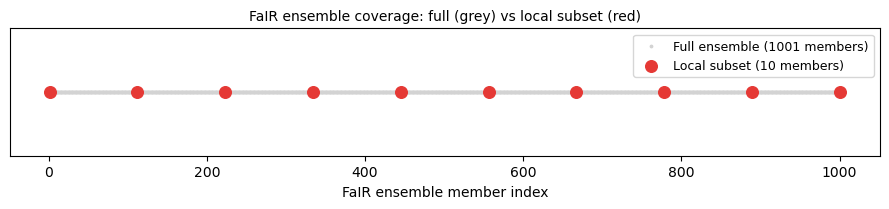

In [9]:
FULL_ENSEMBLE_SIZE = 1001
N_ENSEMBLE_LOCAL   = 10

# Well-distributed subset: linear spacing across the full index range
# JUSTICE uses 1-based ensemble indexing internally
ensemble_indices = list(np.linspace(1, 1000, N_ENSEMBLE_LOCAL, dtype=int))

print(f"Full FaIR ensemble : {FULL_ENSEMBLE_SIZE} members")
print(f"Local subset       : {N_ENSEMBLE_LOCAL} members")
print(f"Selected indices   : {ensemble_indices}")
print(f"Speedup (approx)   : ~{FULL_ENSEMBLE_SIZE // N_ENSEMBLE_LOCAL}×")

# Visualise coverage
fig, ax = plt.subplots(figsize=(9, 2.2))
ax.scatter(range(1, FULL_ENSEMBLE_SIZE + 1), [1] * FULL_ENSEMBLE_SIZE,
           s=3, color='lightgrey', label=f'Full ensemble ({FULL_ENSEMBLE_SIZE} members)', zorder=1)
ax.scatter(ensemble_indices, [1] * N_ENSEMBLE_LOCAL,
           s=70, color='#E53935', zorder=3, label=f'Local subset ({N_ENSEMBLE_LOCAL} members)')
ax.set_xlabel('FaIR ensemble member index', fontsize=10)
ax.set_yticks([])
ax.set_title('FaIR ensemble coverage: full (grey) vs local subset (red)', fontsize=10)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
display(fig)
plt.close(fig)

### Task 5.4 — Define the objectives and ε-resolution

JUSTICE returns four scalar outputs per policy evaluation. You must decide:
- Which to include as **optimisation objectives**
- The **direction** (minimise or maximise)
- The **ε value** — the Pareto archive resolution; smaller ε = finer front = more NFE required

**Question:** What direction should each objective have and what ε-value is appropriate?

> **Answer (as implemented in `run_optimization_local.py`):**
> - `welfare` → **MINIMIZE**, ε = 0.1
> - `fraction_above_threshold` → **MINIMIZE**, ε = 0.25
> - `welfare_loss_damage` → **MAXIMIZE**, ε = 10.0
> - `welfare_loss_abatement` → **MAXIMIZE**, ε = 10.0
>
> All four objectives are physically *lower-is-better*. `welfare` here is an aggregate welfare-**loss** magnitude, and the two `welfare_loss_*` terms are returned by JUSTICE as positive magnitudes (`np.abs()` of the welfare-function output). EMA Workbench's convention for a positive quantity that should be minimised is to declare it as `MAXIMIZE`: the workbench then internally negates the value before passing it to the optimiser, so minimising the negation is equivalent to minimising the original. `welfare` and `fraction_above_threshold` are already in their natural direction and are declared `MINIMIZE` directly.
>
> **For us as Japan & South Korea** the four objectives map straight onto the mandate: `fraction_above_threshold` is our direction-2 climate test (fraction of the ensemble above 2°C in 2100), `welfare_loss_damage` is the channel through which the overshoot interval hurts the exposed regions (`rcam`, `rjan57`), and `welfare_loss_abatement` is the efficiency price that anchors our utilitarian argument and our technology-exporter interest in cheap global decarbonisation.
>
> ε should be proportional to each objective's scale: 0.1 and 0.25 give fine resolution over the 0–1 ranges, while 10.0 gives ~0.1–1% resolution over the 10³–10⁴ welfare-loss range. A practical rule of thumb is to aim for roughly 100–200 solutions in the Pareto set, which usually takes a little trial and error.

In [10]:
from ema_workbench import ScalarOutcome

# ── Objectives aligned with run_optimization_local.py ────────────────────────
objectives = [
    {"name": "welfare",                  "kind": ScalarOutcome.MINIMIZE, "epsilon": 0.1  },
    {"name": "fraction_above_threshold", "kind": ScalarOutcome.MINIMIZE, "epsilon": 0.25 },
    {"name": "welfare_loss_damage",      "kind": ScalarOutcome.MAXIMIZE, "epsilon": 10.0 },
    {"name": "welfare_loss_abatement",   "kind": ScalarOutcome.MAXIMIZE, "epsilon": 10.0 },
]

print(f"  {'Objective':<35} {'Direction':<10}  {'ε':>6}")
print(f"  {'-'*35} {'-'*10}  {'-'*6}")
for obj in objectives:
    direction = "MINIMIZE" if obj["kind"] == ScalarOutcome.MINIMIZE else "MAXIMIZE"
    print(f"  {obj['name']:<35} {direction:<10}  {obj['epsilon']:>6.2f}")

EPSILONS = [obj["epsilon"] for obj in objectives]
print(f"\nε vector: {EPSILONS}")

  Objective                           Direction        ε
  ----------------------------------- ----------  ------
  welfare                             MINIMIZE      0.10
  fraction_above_threshold            MINIMIZE      0.25
  welfare_loss_damage                 MAXIMIZE     10.00
  welfare_loss_abatement              MAXIMIZE     10.00

ε vector: [0.1, 0.25, 10.0, 10.0]


### Task 5.5 — Assemble and save the optimisation configuration

Collect all four decisions into a single JSON config file. `run_optimization_local.py` (Assignment 5) reads this file to set up every run parameter — welfare function, scenario, ensemble size, RBF architecture, objectives, and ε-values.

In [11]:
import json, os

# ── Locate JUSTICE-main config directory ─────────────────────────────────────
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath('.')
_JUSTICE_ROOT = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../JUSTICE-main"))
_CONFIG_DIR   = os.path.join(_NOTEBOOK_DIR, "../config")
os.makedirs(_CONFIG_DIR, exist_ok=True)

# ── Assemble config from all decisions above ──────────────────────────────────
student_config = {
    # Simulation horizon
    "start_year":                       2015,
    "end_year":                         2300,
    "data_timestep":                    5,      # years between raw input data points
    "timestep":                         1,      # model integration timestep (years)
    # Policy start
    "emission_control_start_year":      2025,   # first year ECR can exceed zero
    # RBF architecture: fixed at 4 basis functions x 2 inputs -> 244 decision vars
    "n_rbfs":                           N_RBFS,
    "n_inputs":                         N_INPUTS,
    # Optimisation resolution
    "epsilons":                         EPSILONS,
    # Objective evaluation
    "temperature_year_of_interest":     2100,
    "reference_ssp_rcp_scenario_index": CHOSEN_SCENARIO_INDEX,
}

# ── Validate ──────────────────────────────────────────────────────────────────
assert student_config["n_rbfs"] == 4, "n_rbfs is fixed at 4 for this RBF architecture"
assert len(student_config["epsilons"]) == 4, \
    "Exactly 4 epsilon values required (one per objective)"
assert all(e > 0 for e in student_config["epsilons"]), \
    "All epsilon values must be strictly positive"
assert student_config["emission_control_start_year"] >= student_config["start_year"], \
    "Policy cannot start before the simulation"

# ── Save ──────────────────────────────────────────────────────────────────────
config_path = os.path.join(_CONFIG_DIR, "config_student.json")
with open(config_path, "w") as fh:
    json.dump(student_config, fh, indent=4)

print(f"Config saved → {config_path}")
print()
print(json.dumps(student_config, indent=4))


Config saved → /Users/stijnkeukens/epa141a-main/JUSTICE-main/../config/config_student.json

{
    "start_year": 2015,
    "end_year": 2300,
    "data_timestep": 5,
    "timestep": 1,
    "emission_control_start_year": 2025,
    "n_rbfs": 4,
    "n_inputs": 2,
    "epsilons": [
        0.1,
        0.25,
        10.0,
        10.0
    ],
    "temperature_year_of_interest": 2100,
    "reference_ssp_rcp_scenario_index": 2
}


---
## Reflection Questions

**1. Single-scenario optimisation.** The MOEA optimises under SSP2-RCP4.5 alone. What risk does this introduce?

Optimising under SSP2-4.5 alone produces policies tuned to one specific cost–damage balance, and for our mandate that is a pointed risk. Our whole case rests on a technology-led pathway that is allowed to overshoot 2°C and then return below it, provided near-term damage to the most vulnerable stays bounded. Whether the overshoot actually stays bounded depends on the realised trajectory: under a higher-emission pathway the temperature peak comes later and hotter, and the damage to exposed regions such as `rcam` and `rjan57` is larger, so a policy that satisfies our overshoot criterion under SSP2-4.5 may breach it under SSP3-7.0 or SSP5-8.5. Single-scenario optimisation therefore tends to make our preferred pathway look safer than it is, which is precisely the weakness Bloc 1 will probe. We address it by re-evaluating the reference set across a FaIR ensemble in the robustness analysis (Assignment 8) before committing to a recommendation.

**2. Closed-loop vs. open-loop policies.** The RBF encodes a *decision rule* (react to current climate state) rather than a *decision schedule* (follow a fixed time path). Why is the closed-loop formulation preferable when climate sensitivity is uncertain? What is the computational cost of this flexibility?

A fixed time-path schedule commits to a calendar of cuts regardless of how the climate responds, whereas the RBF maps the current temperature and warming rate to an emission control rate, so the policy self-corrects as the climate evolves. This is the modelling analogue of our central negotiating demand: we argue for technology neutrality, that the agreement should fix the temperature *outcome* and leave the route to each actor, and an outcome-conditioned decision rule does exactly that it targets a state, not a prescribed timetable. It is also genuinely robust under ECS uncertainty: it raises abatement only if warming actually accelerates and spares it if the climate proves less sensitive, which protects the efficiency argument at the heart of our utilitarian case. The cost is dimensionality. Instead of a handful of scalar targets the MOEA must search 244 RBF parameters, which is why the run needs many function evaluations and a reduced FaIR ensemble to stay tractable on a laptop.

**3. FaIR ensemble trade-off.** Using 10 instead of 1001 ensemble members reduces runtime ~100×. What does it sacrifice?

It sacrifices coverage of the distribution tails, and those tails are where our argument is won or lost. The high-ECS members are the ones that turn a temporary, bounded overshoot into a deep and prolonged one, and they drive the worst-case damage to the exposed regions that our prioritarian, worst-off lens is meant to capture. A 10-member subset can therefore make our pathway look safer, and our overshoot shorter, than a full-ensemble evaluation would flattering exactly the claim we most need to defend. The uniform spacing across the index range keeps the subset from systematically favouring low or high sensitivity, so it is a fair approximation for the optimisation stage, but for the final robustness check that underpins our adaptation-finance commitment we would re-evaluate the reference set against a much larger ensemble.